In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('/content/drive/MyDrive/sim_swap_fraud_dataset_50000.csv')

In [3]:
df.head()

,sim_swap_time_gap_minutes,device_change_flag,sim_type_change_flag,imsi_change_flag,iccid_change_flag,otp_and_sim_change_geo_hash_length,recent_sim_activation_days,num_sim_changes_last_30d,previous_sim_holder_tenure_days,account_age_days,ip_change_flag,sim_swap_flag
0,9205,0,0,0,0,0.40,154,4,307,1811,0,0
1,6889,1,1,1,0,0.85,83,5,887,279,0,1
2,1310,0,1,1,0,0.45,331,0,338,1496,1,1
3,1979,1,0,1,0,0.13,11,1,424,576,0,1
4,3671,0,0,1,1,0.28,25,1,193,987,1,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   sim_swap_time_gap_minutes           100000 non-null  int64  
 1   device_change_flag                  100000 non-null  int64  
 2   sim_type_change_flag                100000 non-null  int64  
 3   imsi_change_flag                    100000 non-null  int64  
 4   iccid_change_flag                   100000 non-null  int64  
 5   otp_and_sim_change_geo_hash_length  100000 non-null  float64
 6   recent_sim_activation_days          100000 non-null  int64  
 7   num_sim_changes_last_30d            100000 non-null  int64  
 8   previous_sim_holder_tenure_days     100000 non-null  int64  
 9   account_age_days                    100000 non-null  int64  
 10  ip_change_flag                      100000 non-null  int64  
 11  sim_swap_flag              

In [5]:
df.isnull().sum()

,0
sim_swap_time_gap_minutes,0
device_change_flag,0
sim_type_change_flag,0
imsi_change_flag,0
iccid_change_flag,0
otp_and_sim_change_geo_hash_length,0
recent_sim_activation_days,0
num_sim_changes_last_30d,0
previous_sim_holder_tenure_days,0
account_age_days,0


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.skew()

,0
sim_swap_time_gap_minutes,0.003132
device_change_flag,0.001560
sim_type_change_flag,0.006360
imsi_change_flag,-0.005520
iccid_change_flag,-0.005920
otp_and_sim_change_geo_hash_length,-0.002861
recent_sim_activation_days,-0.002183
num_sim_changes_last_30d,-0.002266
previous_sim_holder_tenure_days,0.005988
account_age_days,0.001165


In [8]:
df['sim_swap_flag'].value_counts()
df['sim_swap_flag'].value_counts(normalize=True)

,proportion
sim_swap_flag,
1,0.73923
0,0.26077


In [9]:
X = df.drop('sim_swap_flag', axis=1)
y = df['sim_swap_flag']

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [12]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = rf.predict(X_test)
y_probs = rf.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_probs))

[[ 5156    59]
 [   75 14710]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5215
           1       1.00      0.99      1.00     14785

    accuracy                           0.99     20000
   macro avg       0.99      0.99      0.99     20000
weighted avg       0.99      0.99      0.99     20000

ROC-AUC: 0.9997771509890404


In [13]:
threshold = 0.5  # start here (balanced dataset)

y_pred_custom = (y_probs >= threshold).astype(int)

print(confusion_matrix(y_test, y_pred_custom))
print(classification_report(y_test, y_pred_custom))

[[ 5155    60]
 [   73 14712]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5215
           1       1.00      1.00      1.00     14785

    accuracy                           0.99     20000
   macro avg       0.99      0.99      0.99     20000
weighted avg       0.99      0.99      0.99     20000



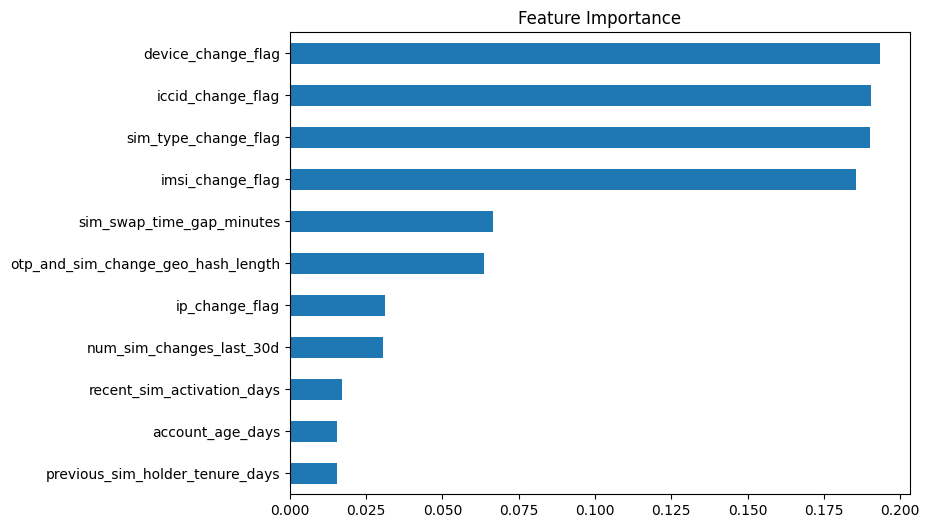

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

importance = rf.feature_importances_
feat_imp = pd.Series(importance, index=X.columns)

feat_imp.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance")
plt.show()

In [15]:
import joblib
joblib.dump(rf, "/content/drive/MyDrive/sim_swap_model_v2.pkl")

['/content/drive/MyDrive/sim_swap_model_v2.pkl']